# <font color="brown">**Heritage Institute of Technology**
# <font color="brown">**Department of AEIE**
# <font color="brown">**MACHINE LEARNING TECHNIQUES LAB (AEI3262)**
# <font color="brown">**B. Tech AEIE,   6th Semester**
# <font color="Blue">**Experiment No. 3: Dimensionality Reduction and Data Visualization </font>**  **[CO: AEI3262.2]**


# <font color="Blue">**Objective:**  

##Reduce high-dimensional data using PCA and t-SNE, and compare their effectiveness.
- Apply PCA and retain optimal number of components using explained variance.
- Visualize transformed data in 2D or 3D.
- Apply t-SNE for 2D or 3D visualization.
- Compare clustering tendencies and class separability in both plots.

# <font color="Blue"> **A: Learning Outcome:**
## After completion of this assignment you will be able to:

*  Perform principal component analysis of a given data set.
*  Visualize the highdimensional data in two or three dimensions.
*  Apply t-SNE transform to a data set and visualize transformed data.

# <font color="Blue">**B. Instructions:**
* You will be using Python 3.
* Avoid using for-loops and while-loops, unless you are explicitly told to do so.
* Do not modify the function name, variable names, comments in cells.
* Write your code where it is asked to write.
* After your coding, run the cell and see your results.

# <font color="Blue">**C. Useful PYTHON Commands**
Some useful PYTHON commands that may be required to perform this experiment are given below:
# <font color="magenta">*Requird Library:*
    numpy     pands    sklearn    matplotlib.pyplot

# <font color="magenta"> *Elementary Functions from numpy:*
    np.sum()   np.cumsum()   np. mean()        np.std()      
    np.cov()   np.dot()      np.linalg.eig()   np.argsort()      

# <font color="magenta">*Functions from matplotlib.pyplot:*
    plt.figure()   plt.plot()     plt.scatter()  plt.title()
    plt.xlabel()   plt.ylabel()   plt.xticks()   plt.yticks()  
    plt.legend()   plt.grid()     plt.show()

# <font color="magenta">*Modules and Methods of sklearn library:*
    sklearn.preprocessing.standardscaler()   
    sklearn.decomposition.PCA()
    pca.fit_transform()              
    pca.explained_variance_ratio_
    sklearn.manifold.TSNE()      

# *For detail information of the modules of sklearn see the following link:*
https://scikit-learn.org/stable/

# <font color="green">**1. Principal Component Analysis (PCA):**

Principal Component Analysis (PCA) is a linear dimensionality reduction technique used to transform high-dimensional data into a lower-dimensional space while preserving maximum variance. PCA works by identifying new orthogonal axes, called principal components, which are linear combinations of the original features. The first principal component captures the maximum variance in the data, and each subsequent component captures the remaining variance under the constraint of orthogonality.

PCA is widely used for:

* Reducing computational complexity
* Removing multicollinearity
* Noise reduction
* Data visualization

The number of components is selected based on the explained variance ratio, ensuring that most of the information in the data is retained.

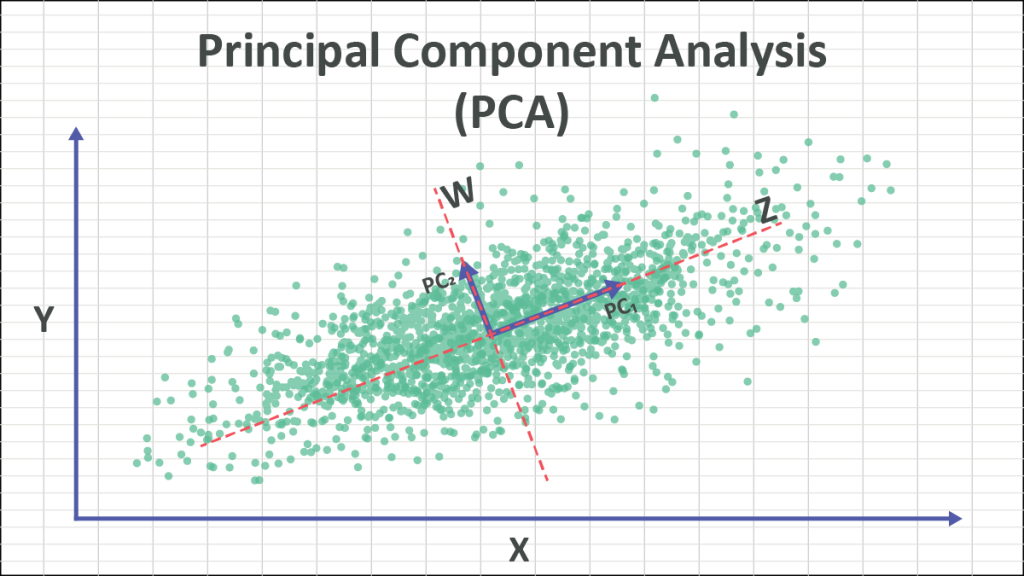

# <font color="green"> **2. PCA Implementation Step by Step from Scratch**

## <font color="blue"> **Problem:**</font>
# 1. Load the iris dataset from **sklearn.datasets** using **import load_iris** and apply **PCA** and **TSNE** on this dataset.

In [ ]:
##Step-1
##Import required Libraries
##============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
##Step-2
##Load data set
##===================================
from sklearn.datasets import load_iris

iris = load_iris()     #Load the data set
X = iris.data          # Feature matrix
y = iris.target        # Class labels
feature_names = iris.feature_names    ##Feature Names
target_names = iris.target_names      ##Target names

df = pd.DataFrame(X, columns=feature_names)  ##Constract a dataframe
df['Class'] = y                              ##Add the class column in the dataframe

print(df.head())                             ##Visualize few rows of dataframe


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Class  
0      0  
1      0  
2      0  
3      0  
4      0  


In [ ]:
##Step-3
##Standardize the data by Zero mean and unit variance
##PCA is scale-sensitive, so standardization is mandatory.
##========================================================
##1. Calculate mean of each feature along axis=0
##2. Calculate standard deviation of each feature along axis=0
##3. Standarize the dataset by subtracting mean and dividing by the std.

## ~~~ Write three lines of code here ~~~
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_standardized = (X - X_mean)/X_std

##Print the mean and standard deviations of standarized features to verify whether mean=0 and std=1 or not
print("Mean after standardization:", np.mean(X_standardized, axis=0))
print("Std after standardization:", np.std(X_standardized, axis=0))


Mean after standardization: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std after standardization: [1. 1. 1. 1.]


In [ ]:
##Step-4
##Compute covariance matrix
##=====================================
##Compute the covariance matrix of the standardized data.
##Ensure that the samples are in column wise.
## ~~~ Write one line of code here ~~~
cov_matrix = np.cov(X_standardized.T)

##Print the covariance matrix to check its dimension.
##It should be (No. of features x No. of features)
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [ ]:
##Step-5
##Compute Eigen values and Eigen vectors
##=========================================
##Compute eigenvalues, eigenvectors of Covariance Matrix
## ~~~ Write one line of code here ~~~
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

##Print Eigen values and Eigen vectors
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)


Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]
Eigenvectors:
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [ ]:
##Step-6
##Sort Eigenvalues and Eigenvectors (Descending order)
##===================================================
##1. Sort the indices of eigen values in descending order
##2. Sort the eigen values in descending order
##3. Sort eigen vectors in descending order
## ~~~ Write three lines of code  here ~~~
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_indices]

eigenvectors_sorted = eigenvectors[:, sorted_indices]

##Print the sorted eigen values
print("Sorted Eigenvalues:\n", eigenvalues_sorted)


Sorted Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]


Explained Variance Ratio:
 [0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative Explained Variance:
 [0.72962445 0.95813207 0.99482129 1.        ]


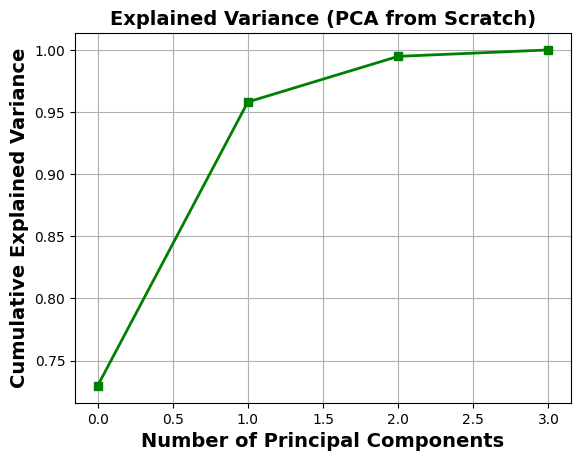

In [ ]:
##Step-7
##Compute Explained Variance Ratio and plot it
##===================================================
##Compute explained variance ratio of sorted eigenvalues and
##cumulative explained variance
## ~~~ Write two lines of code here ~~~
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

##Print the explained variance ratio and cumulative explained variance

print("Explained Variance Ratio:\n", explained_variance_ratio)
print("Cumulative Explained Variance:\n", cumulative_variance)

##Plot the variance ratio
plt.figure()
plt.plot(cumulative_variance, marker='s', linewidth=2, color='green')
plt.xlabel("Number of Principal Components", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.title("Explained Variance (PCA from Scratch)", fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()



In [ ]:
##Step-8
##Decide optimal number of Principal Components that can preserve 95% or more variance
##===================================================
##For simplisity of visualization, let us Select 2 components
k = 2
##Select k numbers eigen direction or principal components
## from the sorted eigen vectors
## ~~~ Write one line of code here ~~~
W = eigenvectors_sorted[:, :k]

##Check the shape of the projection matrix
print("Projection Matrix Shape:", W.shape)


Projection Matrix Shape: (4, 2)


In [ ]:
##Step-9
##Project Data onto Principal Components
##=======================================
##Computation of the projection of the data onto the Principal components
##Compute dot product between standarized data and the projection matrix
## ~~~ Write one line of code here ~~~
X_pca = np.dot(X_standardized, W)

##Print the shape of the transformed data
print("Reduced Data Shape:", X_pca.shape)


Reduced Data Shape: (150, 2)


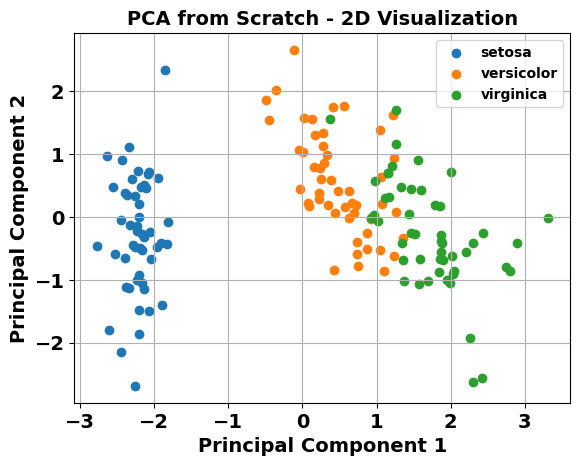

In [ ]:
##Step-10
##Visualize the PCA transformed data set in 2D
##=======================================
plt.figure()

##Perform scatter plot of transformed data
##Plot compnent 1 vs. component 2 for all samples of different target classes
for i, target in enumerate(target_names):
    ## ~~~ Write one line of code here ~~~
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1], label=target)

#Set labels, titles, etc.
plt.xlabel("Principal Component 1", fontsize=14, fontweight='bold')
plt.ylabel("Principal Component 2", fontsize=14, fontweight='bold')
plt.title("PCA from Scratch - 2D Visualization", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper right')
plt.grid(True)
plt.show()


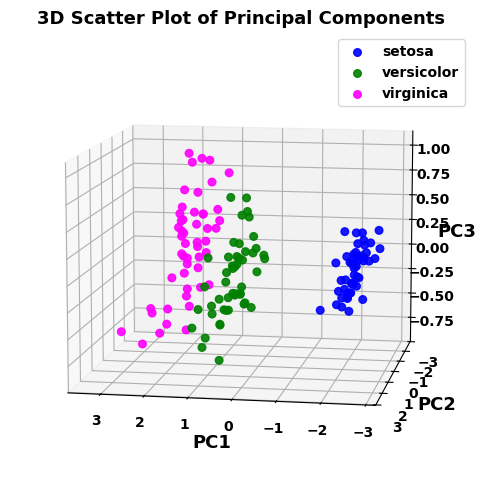

In [ ]:
##Visualize the PCA transformed data set in 3D
##============================================
##Import library for 3D plot
from mpl_toolkits.mplot3d import Axes3D

##Select 3 principal components from the sorted eigen vectors
## ~~~ Write one line of code here ~~~
k=3
W3 = eigenvectors_sorted[:, :k]

##Project the standarized data long the three principal direction
## ~~~ Write one line of code here ~~~
X_pca_3D = np.dot(X_standardized, W3)

##Plot the PCA transformed data in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

##Choose colors of the three target classes
colors = ['blue', 'green', 'magenta']

for i, target in enumerate(target_names):
    ##Plot compnent 1 vs. component 2 vs. component 3 for all samples
    ##    of different target classes with different colors
    ## ~~~ Write one line of code here ~~~
    ax.scatter(X_pca_3D[y==i, 0], X_pca_3D[y==i, 1], X_pca_3D[y==i, 2], s=30, color= colors[i],    alpha=0.9, label=target)

#Set labels, titles, etc.
ax.set_xlabel('PC1', fontsize=13, fontweight='bold')
ax.set_ylabel('PC2', fontsize=13, fontweight='bold')
ax.set_zlabel('PC3', fontsize=13, fontweight='bold')
ax.set_title('3D Scatter Plot of Principal Components',
                        fontsize=13, fontweight='bold')
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
for tick in ax.get_zticklabels():
    tick.set_fontweight('bold')

#Adjust the elevation and azimuth angles for better view
ax.view_init(elev=10, azim=100)

ax.legend(fontsize=12, prop={'weight': 'bold'})
plt.show()


# <font color="green"> **3. Implementation of PCA using functions from sklearn**

## <font color="blue"> **Problem-2:**</font>
# Implement the problem-1 using library functions.

Dataset Shape: (150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Class  
0      0  
1      0  
2      0  
3      0  
4      0  

Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative Explained Variance: [0.72962445 0.95813207 0.99482129 1.        ]


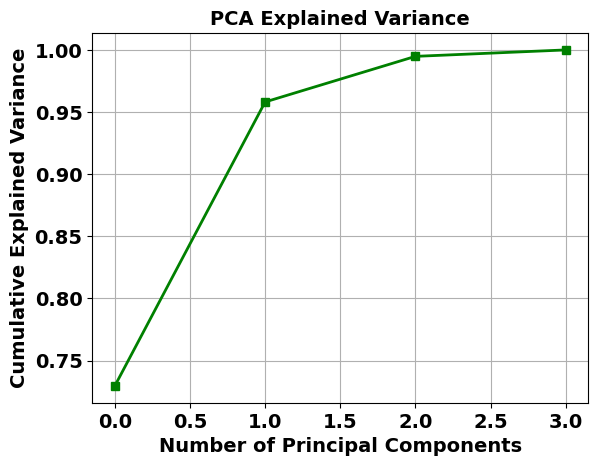

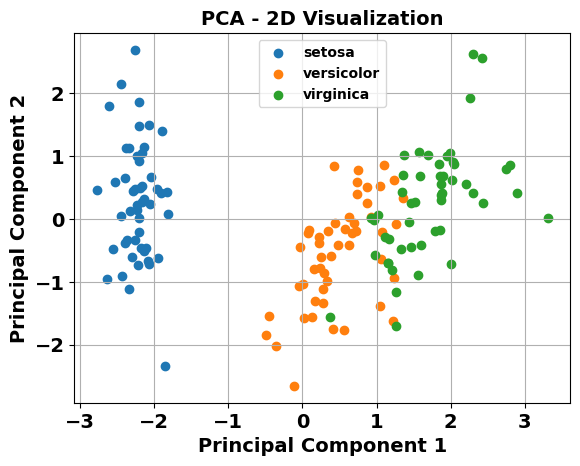

In [ ]:
## Import the libraries and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

df = pd.DataFrame(X, columns=iris.feature_names)
df['Class'] = y

print("Dataset Shape:", df.shape)
print(df.head())

# --------------------------------------------
# Step 2: Standardize the data
# Use: StandardScaler() function to scale the features by zero mean
#      and unity variance
# --------------------------------------------
#Import standardScaler and fit it on the data set to apply transorm
## ~~~ Write two lines of code here ~~~
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# Step 3: Apply PCA() function to the scaled data
# --------------------------------------------
## 1. Assign the PCA() methods to a varibale
## 2. Apply the method to fit the transform on scaled data set
## ~~~ Write two lines of code here ~~~
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

##Compute Explained variance ratio from the pca transform
## ~~~ Write one line of code here ~~~
explained_variance = pca.explained_variance_ratio_

##Compute cumulative explained variance
## ~~~ Write one line of code here ~~~
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio:", explained_variance)
print("Cumulative Explained Variance:", cumulative_variance)

# --------------------------------------------
# Step 4: Plot cumulative variance
# --------------------------------------------
plt.figure()

## ~~~ Write one line of code here to plot cumulative variance ~~~
plt.plot(cumulative_variance, marker='s', linewidth=2, color='green')

##Set the labels, titles, etc.
plt.xlabel("Number of Principal Components", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.title("PCA Explained Variance", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()

# --------------------------------------------
# Step 5: PCA with optimal components (2D)
# --------------------------------------------
##1. Set no. of PCA components to use in PCA method and assign it a variable
##2. Fit the set pca transform on scaled data set
## ~~~ Write two lines of code here ~~~
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

##Plot the transformed data set in 2D
plt.figure()
for i, target in enumerate(target_names):
    ##Perform scatter plot of transformed data
    ##Plot component 1 vs. component 2 for all samples of different target classes
    ## ~~~ Write one lines of code here ~~~
    plt.scatter(X_pca_2[y==i, 0], X_pca_2[y==i, 1], label=target)

##Set the labels, titles, etc.
plt.xlabel("Principal Component 1", fontsize=14, fontweight='bold')
plt.ylabel("Principal Component 2", fontsize=14, fontweight='bold')
plt.title("PCA - 2D Visualization", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper center')
plt.grid(True)
plt.show()




# <font color="green">**2. t-Distributed Stochastic Neighbor Embedding (t-SNE):**

**t-Distributed Stochastic Neighbor Embedding (t-SNE)** is a non-linear dimensionality reduction technique primarily used for data visualization. It maps high-dimensional data into a lower-dimensional space (usually 2D or 3D) by preserving local neighborhood relationships. Points that are close in high-dimensional space remain close in the reduced space.

**t-SNE is particularly effective for:**

* Visualizing complex data structures
* Identifying clusters
* Analyzing class separability

Unlike PCA, t-SNE does not preserve global distances and is computationally intensive, making it unsuitable for feature extraction but highly effective for visualization.

## <font color="blue"> **Problem-3:**</font>
#Perform the TSNE transform on the iris dataset and display the same.

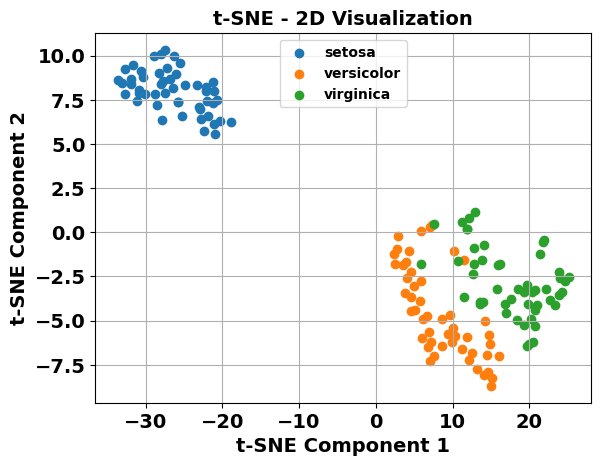

In [ ]:
# --------------------------------------------
# Apply t-SNE for 2D visualization
# --------------------------------------------
##Import TSNE library from sklearn.manifold
from sklearn.manifold import TSNE


#Import standardScaler and fit it on the data set to apply transorm
from sklearn.preprocessing import StandardScaler
## ~~~ Write two lines of code here ~~~
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##Set the no. of components, perplexity and random_state to use in TSNE method
tsne = TSNE(n_components=2, perplexity=20, random_state=None)

##Fit the set tsne transform on scaled data set
## ~~~ Write one line of code here ~~~
X_tsne = tsne.fit_transform(X_scaled)

##Perform scatter plot of the TSNE transformed data in 2D for visualization
plt.figure()
for i, target in enumerate(target_names):
    ##Plot compnent 1 vs. component 2 for all samples of different target classes
    ## ~~~ Write one line of code here ~~~
    plt.scatter(X_tsne[y==i, 0], X_tsne[y==i, 1], label=target)

##Set the labels, titles, etc.
plt.xlabel("t-SNE Component 1", fontsize=14, fontweight='bold')
plt.ylabel("t-SNE Component 2", fontsize=14, fontweight='bold')
plt.title("t-SNE - 2D Visualization", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper center')
plt.grid(True)
plt.show()

## <font color="Green"> **Assignment:**</font>
# 1. Load the wine dataset from **sklearn.datasets** using **import load_wine** and apply **PCA** and **TSNE** on this dataset.